In [16]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Understanding data set
the columns are :
- Gender : male , female
- Age : persons age 
- Height : persons height 
- family_history_with_overweight : this column tells the family history with overweight 
- FAVC : this column has the information about the frequent consumption of high calorie food
- FCVC : this column has the information about the frequent consuption of vegetables 
- NCP : this column has the information about the number of main meals per day 
- CAEC : this column has the information about the sonsumption of food between the main meals
- Smoke : this column has the information about the persons smoke consumption 
- CH2O : this column has the information about the daily water consumption
- SCC : this column has the information about the calories consumption monitoring 
- FAF : this column has the information about the frequent involvement in physical activities 
- TUE : this column has the information about the time in technological devices used 
- CALC : this column has the information about the frequent alchohol consumtion
- MTRANS : this column has the information about the means of transportance used by the persons
- NObeyesedad : this column ahs the inforamtion aboout nutritional obesity level based on BMI

In [18]:
df=pd.read_csv('/Users/lalithavemalapalli/Downloads/ObesityDataSet_raw_and_data_sinthetic 2.csv')

In [19]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


#### Here we are finding the nature of each column in the dataset

In [20]:
dtype = df.dtypes
dtype

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

#### Here we are creting the list of all the numerical dtype columns and name as numerical_columns

In [21]:
numerical_columns = df.select_dtypes(include=['number']).columns
print("Numerical columns:", numerical_columns.tolist())


Numerical columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


#### Here we are analyzing how the numerical data is distributed across each column

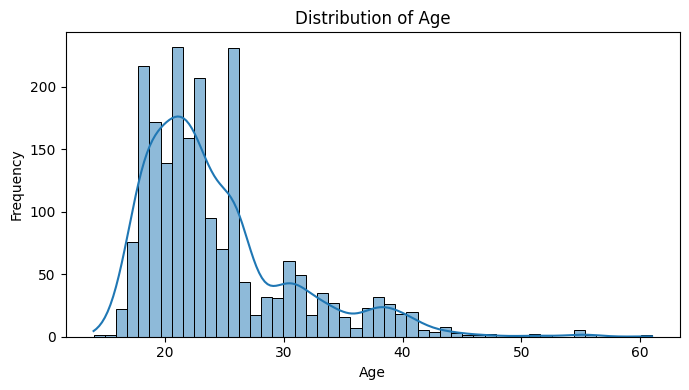

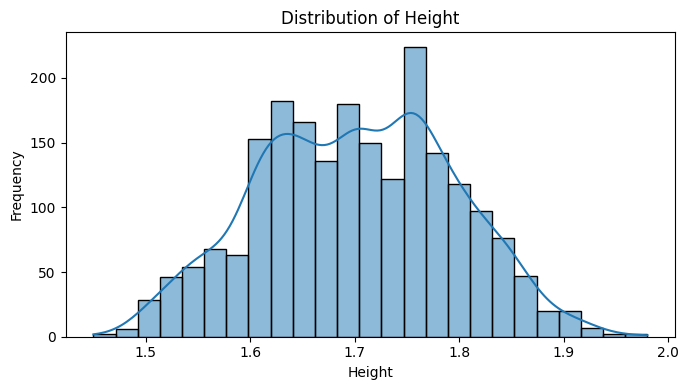

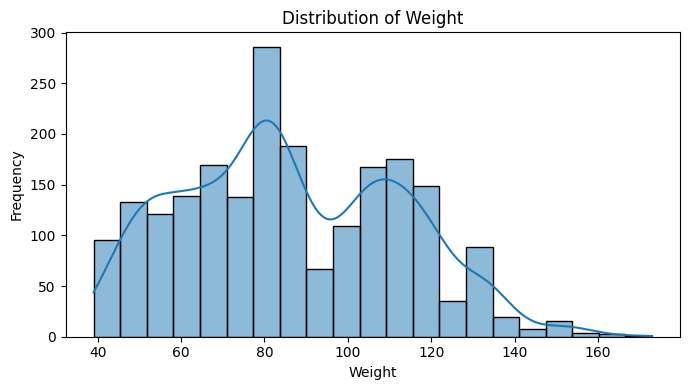

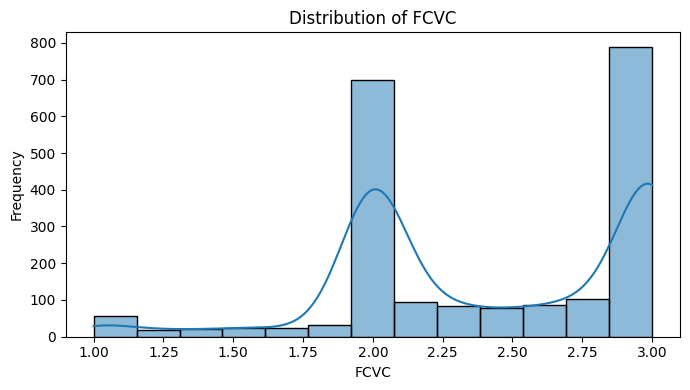

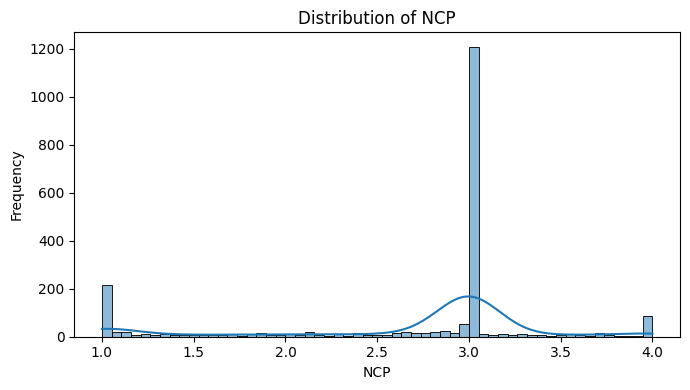

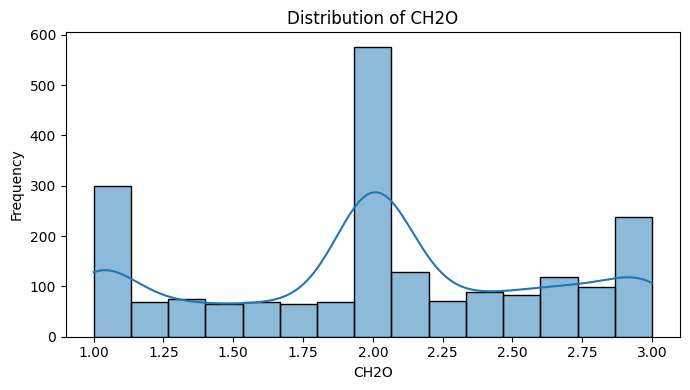

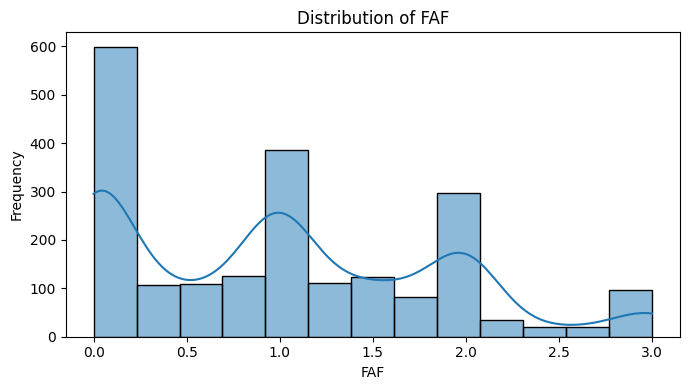

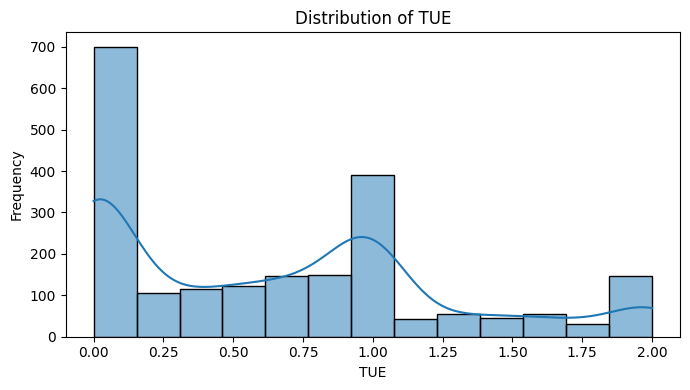

In [22]:
# Plot histogram + KDE for each numerical column
for col in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


#### Here we are manually creating the list of non-numerical data columns and naming it as categorical_cols and analyaing the distribution of data across each column 

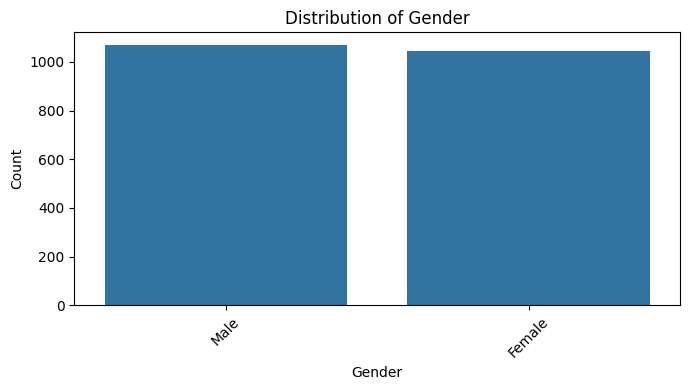

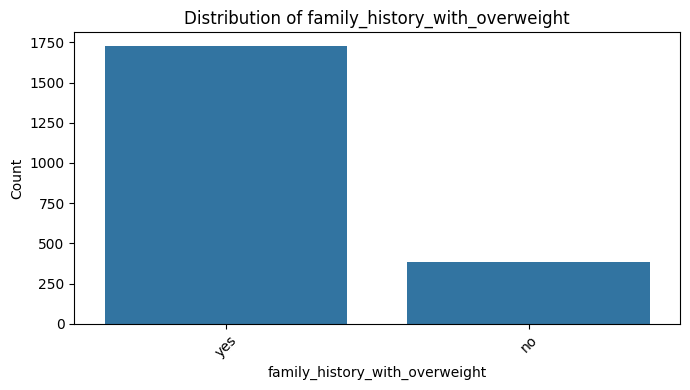

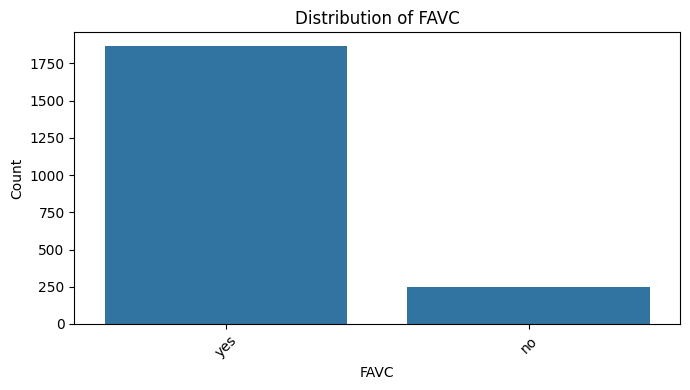

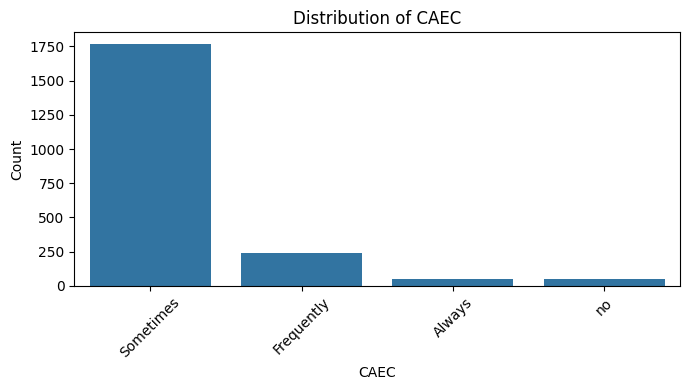

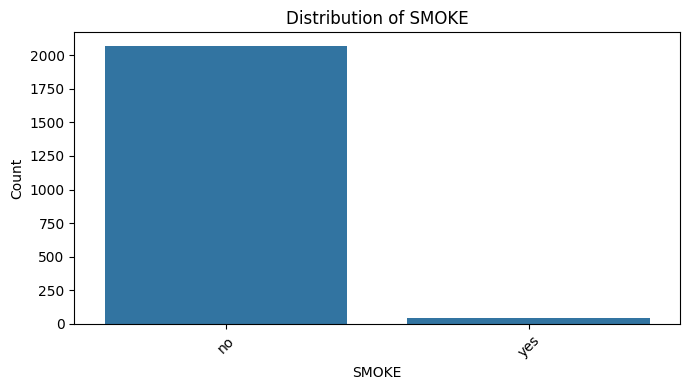

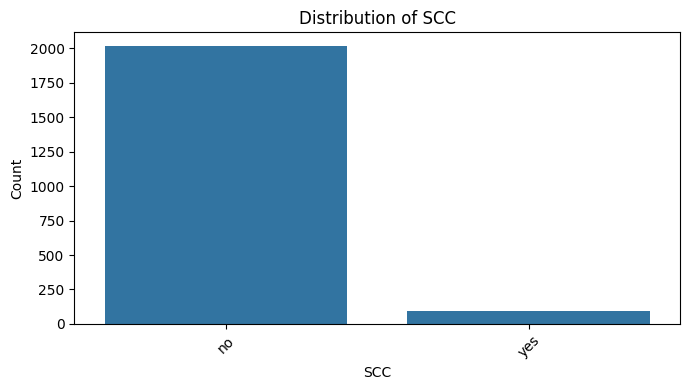

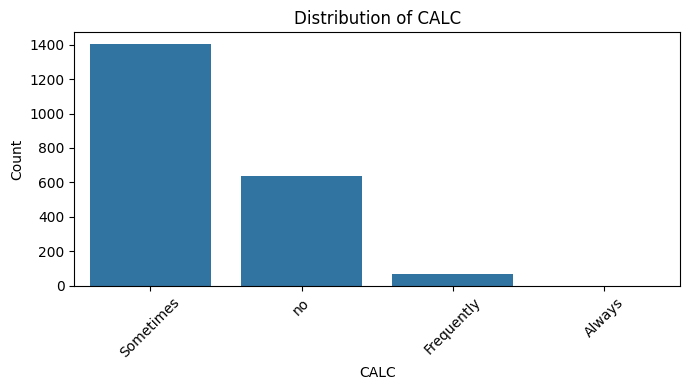

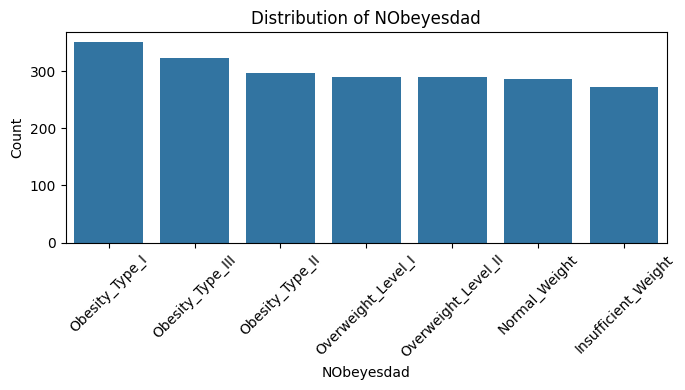

In [23]:
categorical_cols = [
    'Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 
    'SCC', 'CALC', 'NObeyesdad'
]

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


#### Here we are countung the outliers for a;; the numerical columns . Here we are taking the IQR (inter quartile range method), this method calculates the outliers by taking the ranges as quartiles 

In [24]:
numerical_columns = df.select_dtypes(include='number').columns
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = outliers.shape[0]
    
    print(f"Column: {col}")
    print(f"  Q1: {Q1}")
    print(f"  Q3: {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Lower Bound: {lower_bound}")
    print(f"  Upper Bound: {upper_bound}")
    print(f"  Outliers Count: {outlier_count}")
    if outlier_count > 0:
        print(f"  Outlier Values: {outliers[col].tolist()}")
    print("-" * 40)


Column: Age
  Q1: 19.947192
  Q3: 26.0
  IQR: 6.052807999999999
  Lower Bound: 10.867980000000003
  Upper Bound: 35.079212
  Outliers Count: 168
  Outlier Values: [41.0, 52.0, 39.0, 55.0, 38.0, 61.0, 44.0, 36.0, 38.0, 40.0, 55.0, 45.0, 38.0, 39.0, 41.0, 41.0, 40.0, 51.0, 56.0, 39.0, 38.0, 38.0, 38.0, 41.0, 40.0, 37.0, 40.0, 37.0, 41.0, 36.0, 37.0, 38.0, 36.0, 45.0, 41.823567, 35.125401, 36.769646, 35.194089, 37.218161, 42.24475, 37.455752, 40.0, 38.943282, 35.483601, 40.0, 38.939448, 39.965474, 38.692265, 38.952866, 36.631456, 39.214514, 38.825189, 35.217173, 55.24625, 42.189023, 38.464538, 37.496175, 50.832559, 36.310292, 43.238402, 45.0, 55.137881, 38.378056, 39.170029, 46.491859, 38.384177, 37.205173, 37.492444, 35.456326, 39.392569, 37.275298, 55.022494, 41.743333, 38.097395, 37.642177, 47.7061, 35.719457, 35.432059, 39.585811, 45.821267, 39.759575, 43.604901, 42.31607, 37.356288, 40.821515, 37.955371, 40.317787, 35.389491, 40.951591, 39.135634, 37.832949, 37.631769, 37.524551, 43.

#### Here we are checking whether there are any missing values are there are not using the isnull() function

In [25]:
missing_values = df.isnull().sum()

In [26]:
missing_values

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64